In [1]:
import scanpy as sc
import numpy as np
import flowkit as fk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
from preprocessing import read_flow
fcs_dir = str(input("Path"))
tissue_type = input(str("Tissue type"))
df_flow, sample_list, session = read_flow(fcs_dir)

Parameters: Index(['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A',
       'FOXP3', 'CD66bCD19CD326LD', 'CXCR5', 'Ki67', 'CD103', 'CXCR3',
       'CD45RA', 'CD25', 'CD69', 'CD56', 'CD4', 'PD1', 'CD8', 'TCRva', 'CD3',
       'gdTCR', 'CCR7', 'IgE', 'CD28', 'RORgt', '41BB', 'CRTH2', 'CXCR6',
       'CD57', 'IL33R', 'CD45', 'Time', 'sample_id', 'condition', 'CD193',
       'TCRVaJa', '4-1BB', 'PD-1'],
      dtype='object')


In [14]:
df_flow['PD1'] = df_flow[['PD1', 'PD-1']].max(axis=1)
df_flow['TCRva'] = df_flow[['TCRva', 'TCRVaJa']].max(axis=1)
df_flow['41BB'] = df_flow[['41BB', '4-1BB']].max(axis=1)
df_flow['CD103'] = df_flow[['CD103', 'CD193']].max(axis=1)

In [15]:
df_flow.drop(columns = ['PD-1', 'TCRVaJa', '4-1BB', 'CD193'], inplace=True)

In [16]:
exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-B-A', 'SSC-B-H', 'SSC-H', 'AF-A', 'CD66bCD19CD326LD', 'Time', 'CD45']
df_flow = df_flow.drop(columns=exclude)

In [19]:
df_flow_counts = df_flow.select_dtypes(include=[np.number])

In [20]:
from preprocessing import pd_to_adata
adata = pd_to_adata(df_flow, df_flow_counts)

In [21]:
sc.pp.scale(adata, max_value=5)

In [22]:
adata

AnnData object with n_obs × n_vars = 8511386 × 24
    obs: 'group', 'sample_id'
    var: 'mean', 'std'

In [23]:
adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = adata[adata.obs['group'] == group].copy()
    n_cells = group_data.shape[0] 
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)

adata_filtered = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [24]:
CD3 = adata[(adata[:, 'CD3'].X > 0)]
CD3 = CD3[:, CD3.var.index != 'CD3']
adata_list = [
    CD3[CD3.obs['group'] == group].copy()[np.random.choice(
        CD3[CD3.obs['group'] == group].shape[0], 20000, replace=False
    )]
    for group in ['ctr', 'hst', 'ftl']
]

for i, group in enumerate(['ctr', 'hst', 'ftl']):
    adata_list[i].obs['group'] = group

CD3 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [25]:
adata = adata[(adata[:, 'CD3'].X > 0)]
adata = adata[:, adata.var.index != 'CD3']
adata

View of AnnData object with n_obs × n_vars = 3776229 × 23
    obs: 'group', 'sample_id'
    var: 'mean', 'std'

In [26]:
CD4 = adata[(adata[:, 'CD4'].X > 0)]
CD4 = CD4[:, CD4.var.index != 'gdTCR']
CD4 = CD4[:, CD4.var.index != 'TCRva']
CD4 = CD4[:, CD4.var.index != 'CD4']
CD4 = CD4[:, CD4.var.index != 'CD8']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD4[CD4.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)
    
CD4 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [27]:
CD8 = adata[(adata[:, 'CD8'].X > 0)]
CD8 = CD8[:, CD8.var.index != 'gdTCR']
CD8 = CD8[:, CD8.var.index != 'TCRva']
CD8 = CD8[:, CD8.var.index != 'CD4']
CD8 = CD8[:, CD8.var.index != 'CD8']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = CD8[CD8.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)
    
CD8 = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [28]:
gdTCR = adata[(adata[:, 'gdTCR'].X > 0)]
gdTCR = gdTCR[:, gdTCR.var.index != 'gdTCR']
gdTCR = gdTCR[:, gdTCR.var.index != 'TCRva']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = gdTCR[gdTCR.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)
    
gdTCR = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [29]:
TCRva = adata[(adata[:, 'TCRva'].X > 0)]
TCRva = TCRva[:, TCRva.var.index != 'gdTCR']
TCRva = TCRva[:, TCRva.var.index != 'TCRva']

adata_list = []
for group in ['ctr', 'hst', 'ftl']:
    group_data = TCRva[TCRva.obs['group'] == group].copy()
    n_cells = group_data.shape[0]
    n_sample = min(20000, n_cells)
    sampled_indices = np.random.choice(n_cells, n_sample, replace=False)
    group_sample = group_data[sampled_indices]
    group_sample.obs['group'] = group
    adata_list.append(group_sample)
    
TCRva = sc.AnnData.concatenate(*adata_list, index_unique=None)

In [156]:
sample = TCRva
sample_name = 'TCRva'

In [157]:
sc.settings.verbosity = 3

In [158]:
plt.rcParams.update({'font.size': 10})  

computing PCA
    with n_comps=20
    finished (0:00:00)


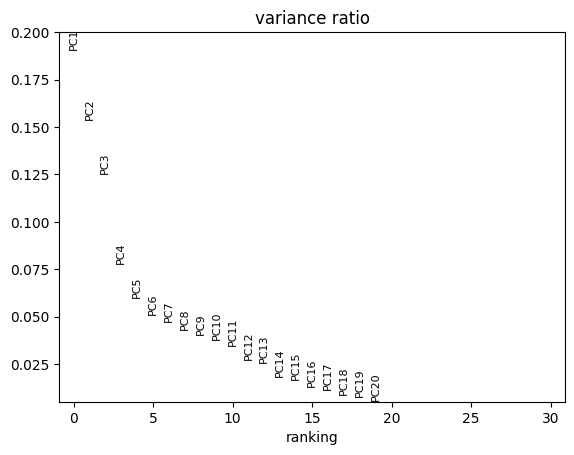

In [159]:
sc.tl.pca(sample, svd_solver="arpack")
sc.pl.pca_variance_ratio(sample, log=False)

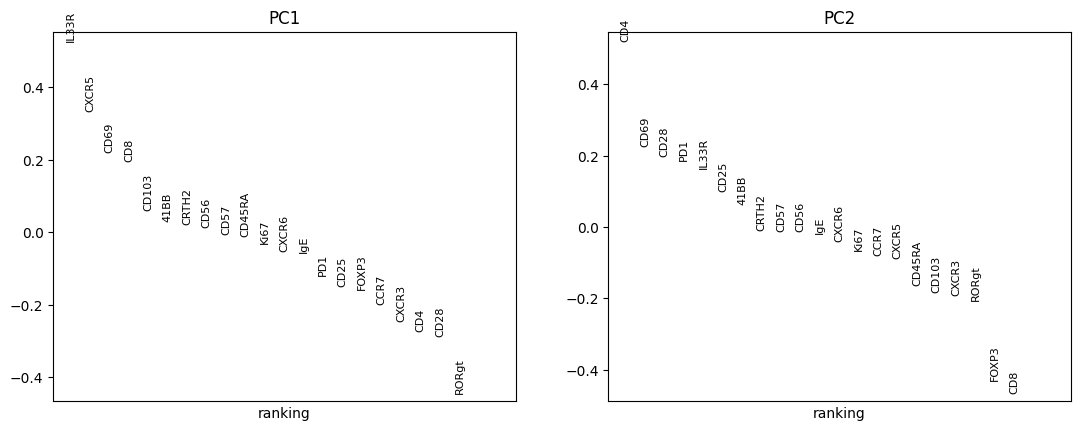

In [160]:
sc.pl.pca_loadings(sample, components = '1,2')

In [161]:
from preprocessing import pca_df
grouped_pca = pca_df(sample, session)

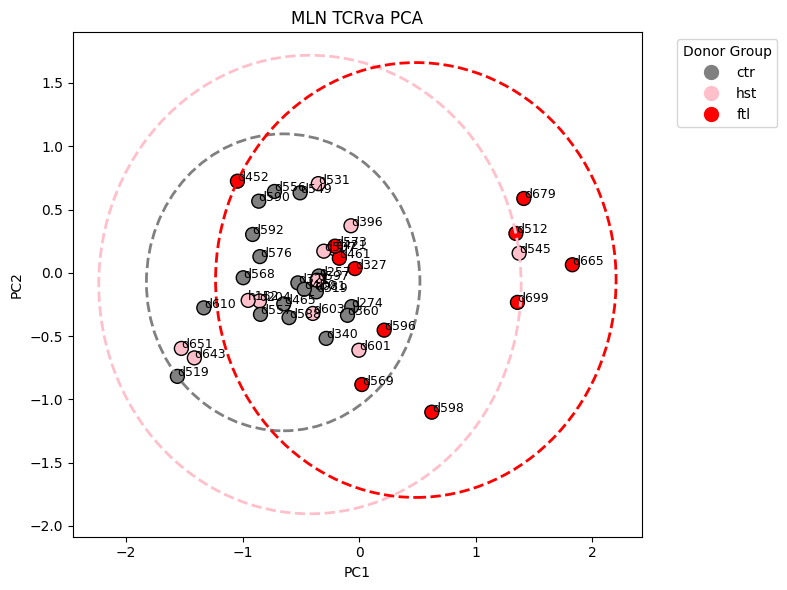

In [162]:
from plotting_methods import pca_plot
pca_plot(grouped_pca, tissue_type, sample_name)

In [163]:
sc.external.pp.harmony_integrate(sample, key='sample_id', max_iter_harmony=20)
sc.pp.neighbors(sample, use_rep='X_pca_harmony')
sc.tl.umap(sample)

2026-01-09 14:34:15,966 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-01-09 14:34:20,577 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-01-09 14:34:20,939 - harmonypy - INFO - Iteration 1 of 20
2026-01-09 14:34:43,915 - harmonypy - INFO - Iteration 2 of 20
2026-01-09 14:35:05,733 - harmonypy - INFO - Iteration 3 of 20
2026-01-09 14:35:27,283 - harmonypy - INFO - Iteration 4 of 20
2026-01-09 14:35:48,827 - harmonypy - INFO - Iteration 5 of 20
2026-01-09 14:36:10,314 - harmonypy - INFO - Iteration 6 of 20
2026-01-09 14:36:31,797 - harmonypy - INFO - Iteration 7 of 20
2026-01-09 14:36:49,592 - harmonypy - INFO - Iteration 8 of 20
2026-01-09 14:37:07,391 - harmonypy - INFO - Iteration 9 of 20
2026-01-09 14:37:27,024 - harmonypy - INFO - Iteration 10 of 20
2026-01-09 14:37:44,002 - harmonypy - INFO - Iteration 11 of 20
2026-01-09 14:37:59,108 - harmonypy - INFO - Iteration 12 of 20
2026-01-09 14:38:14,182 - harmonypy - INFO - Iteration 13 of

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:43)


In [164]:
markers = list(sample.var_names)

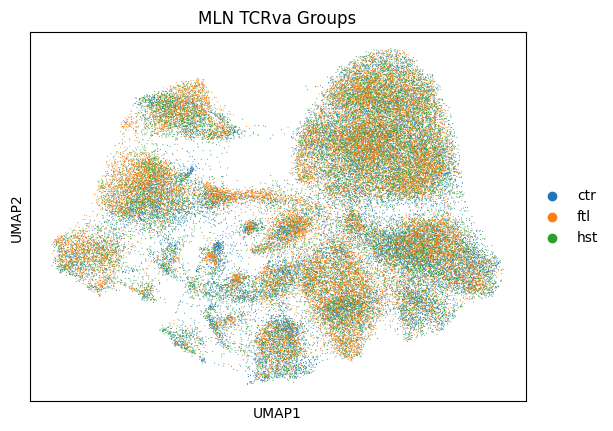

In [165]:
sc.pl.umap(sample, color= ['group'], cmap='turbo', title = '{} {} Groups'.format(tissue_type, sample_name))

In [166]:
sc.tl.leiden(sample, resolution=0.6, flavor='leidenalg')

running Leiden clustering
    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:59)


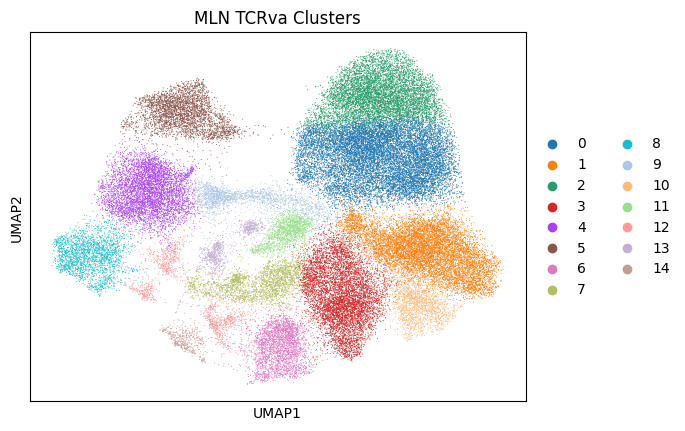

In [167]:
sc.pl.umap(sample, color= ['leiden'], cmap='turbo', title = '{} {} Clusters'.format(tissue_type, sample_name))

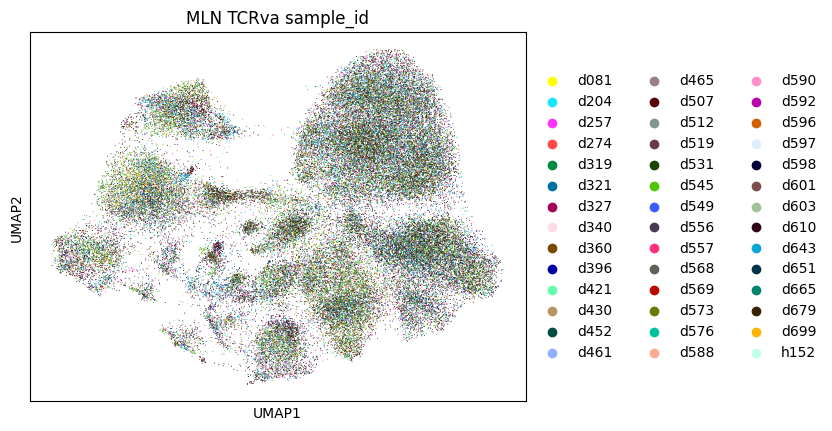

In [168]:
sc.pl.umap(sample, color= ['sample_id'], cmap='turbo',  title = '{} {} sample_id'.format(tissue_type, sample_name))

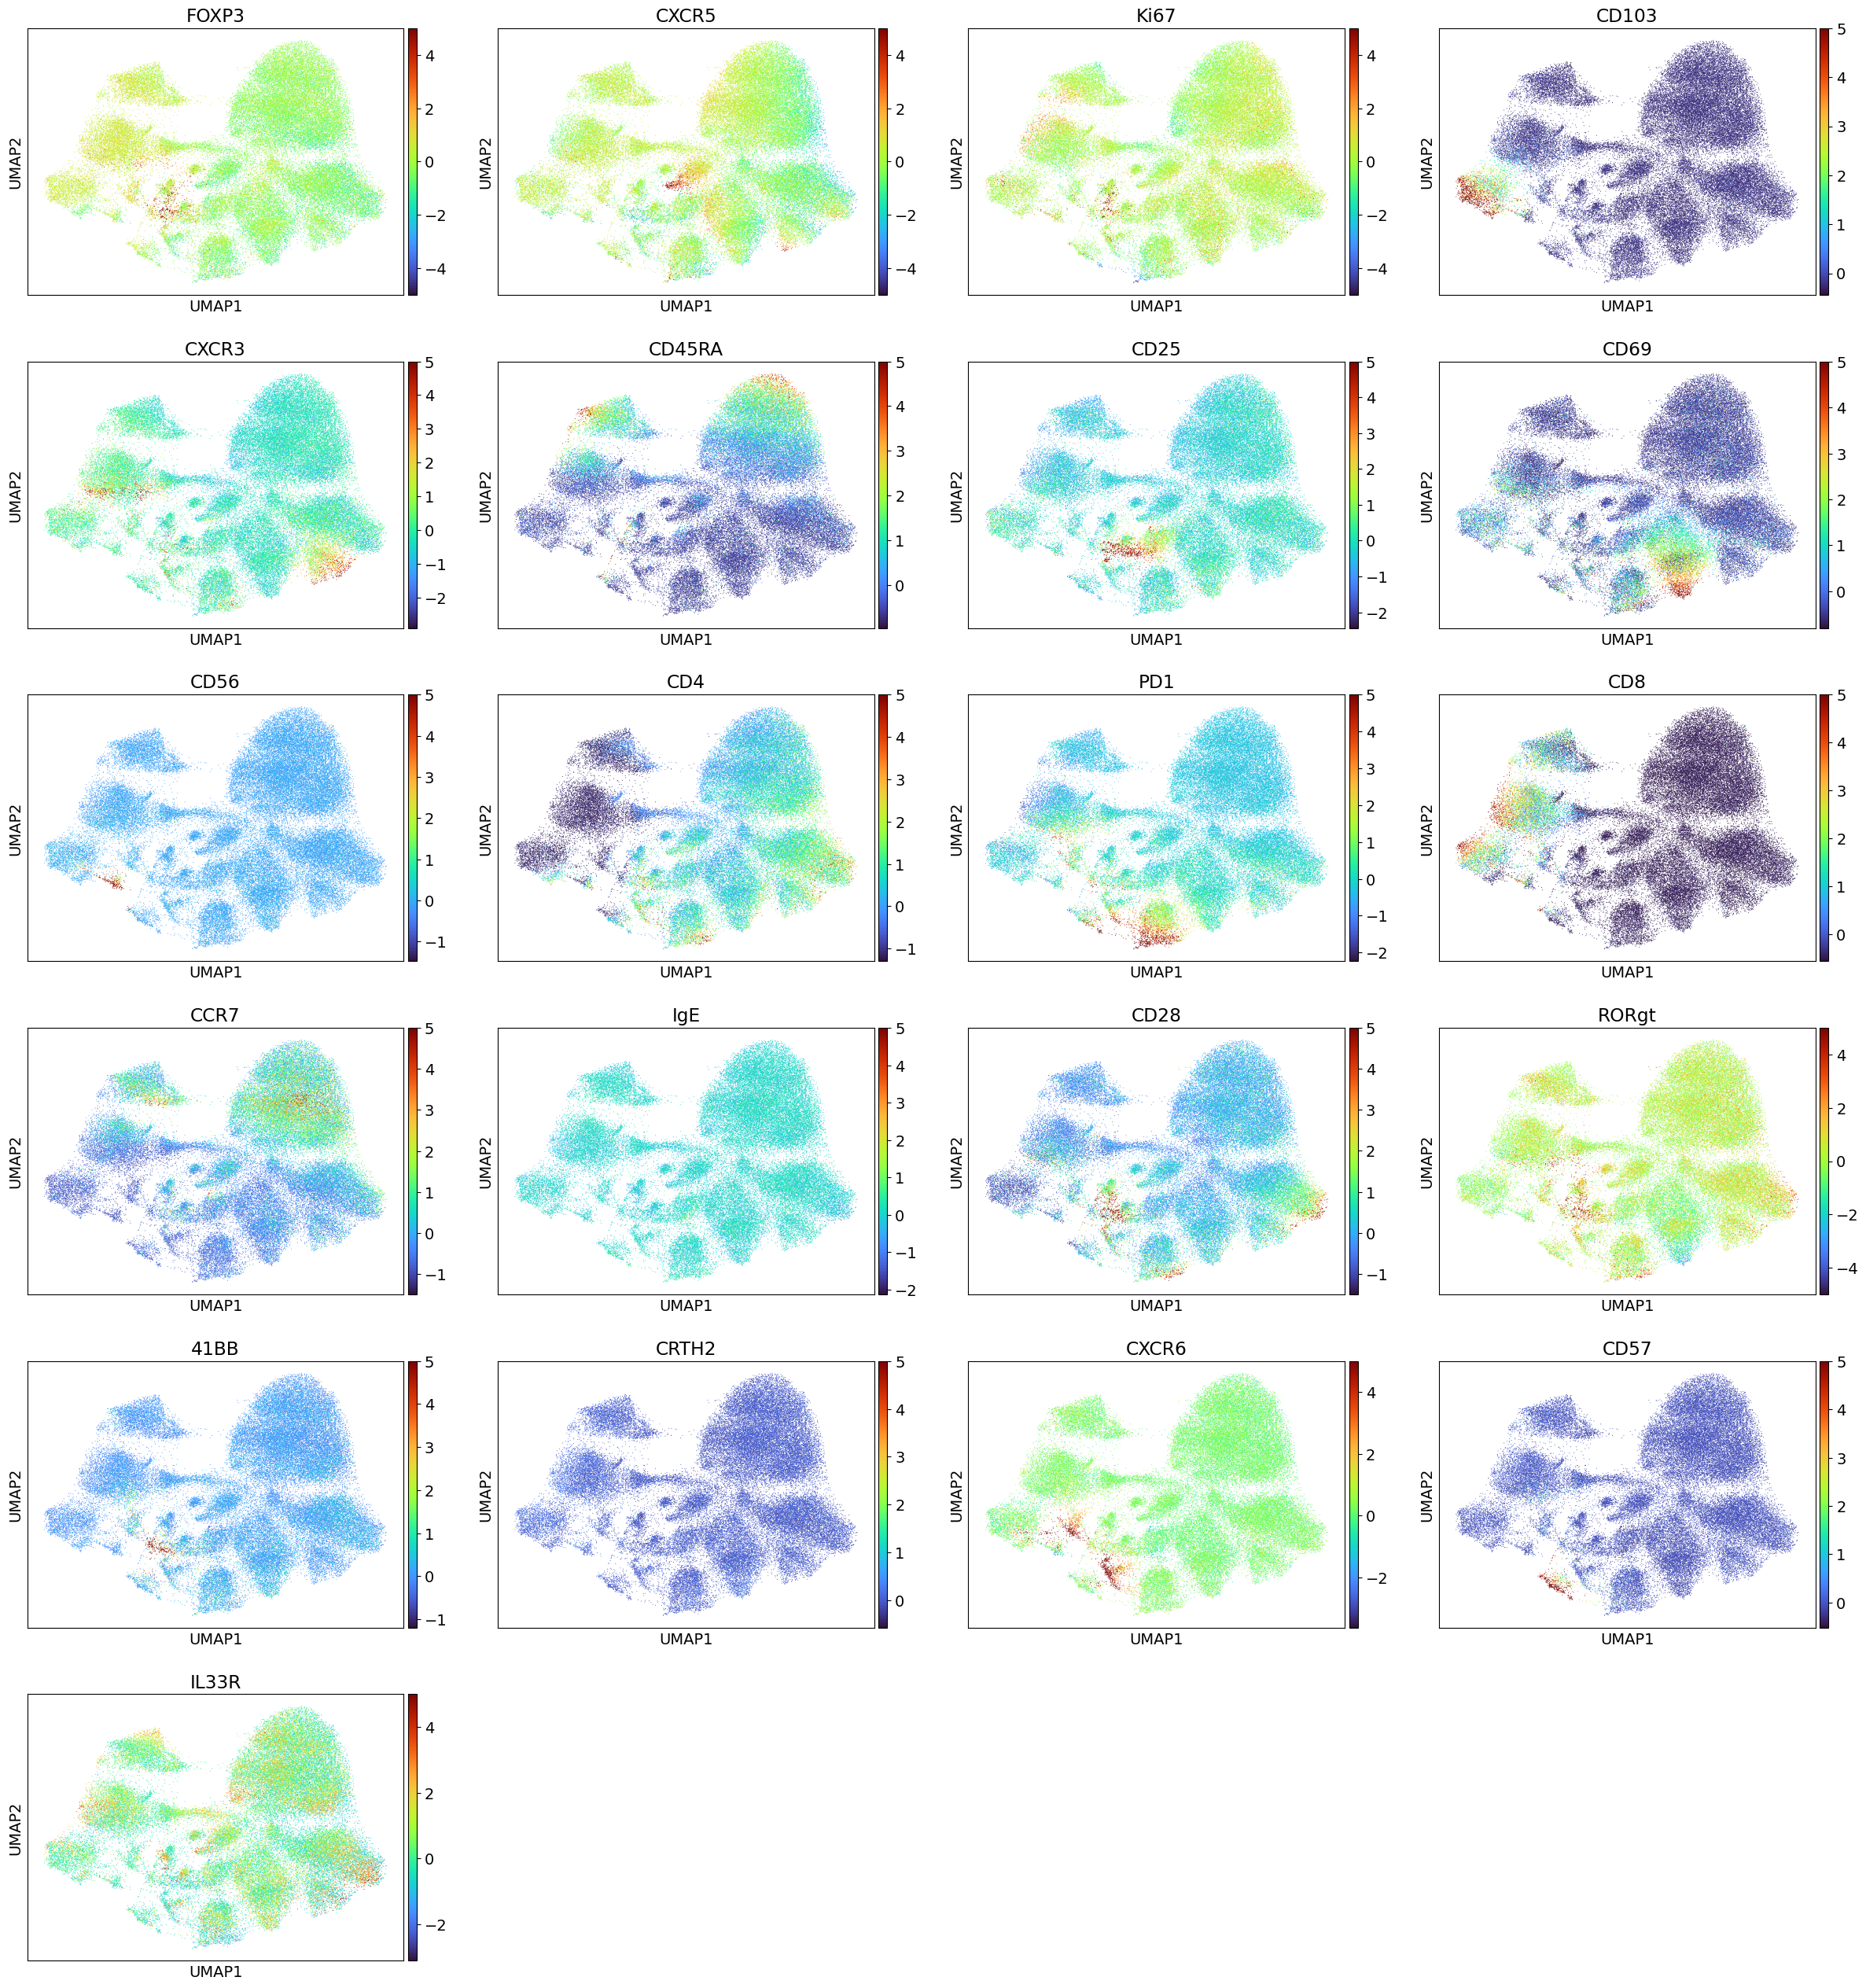

In [169]:
plt.rcParams.update({'font.size': 14})  
sc.pl.umap(sample, color=markers, cmap='turbo')

In [170]:
sc.tl.rank_genes_groups(sample, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: sample.uns["rank_genes_groups"]["names"][group] for group in sample.uns["rank_genes_groups"]["names"].dtype.names}
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


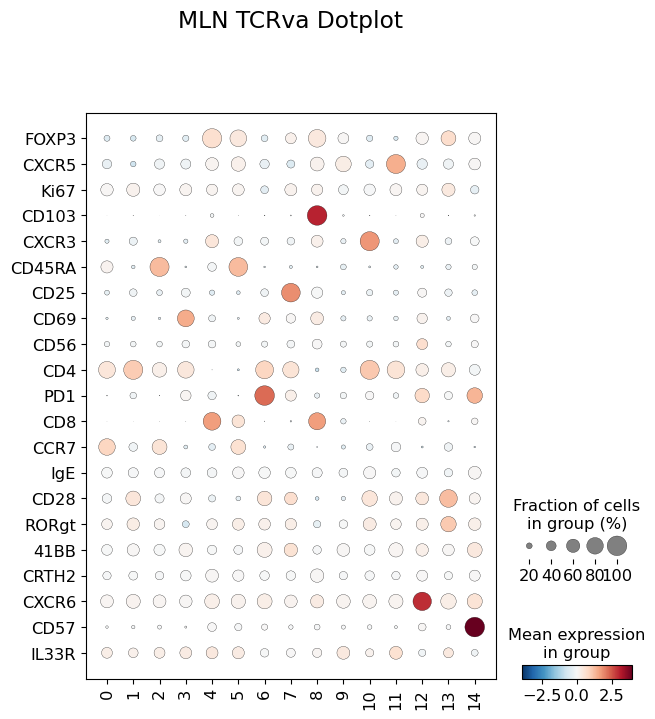

In [171]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

In [173]:
celltype = {'celltype': []}
cluster_to_genes = {
    '0': 'CD4+CCR7+ (0)',
    '1': 'CD4+ (1)',
    '2': 'CD45RA+CD4+CCR7+ (2)',
    '3': 'CD69+CD4+ (3)',
    '4': 'FOXP3+CD8+ (4)',
    '5': 'FOXP3+CD45RA+CD8+CCR7+ (5)',
    '6': 'CD4+PD1+ (6)',
    '7': 'CD25+CD4+ (7)',
    '8': 'CD103+CD8+ (8)',
    '9': 'CXCR5+ (9)',
    '10': 'CXCR3+CD4+ (10)',
    '11': 'CXCR5+CD4+ (11)',
    '12': 'CD4+PD1+CXCR6+ (12)',
    '13': 'FOXP3+CD28+RORgt+ (13)',
    '14': 'PD1+CD57+'


}
celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
sample.obs["celltype"] = celltype['celltype']

print(sample.obs[["leiden", "celltype"]].head())

       leiden              celltype
222848      4        FOXP3+CD8+ (4)
12171       6          CD4+PD1+ (6)
151436      3         CD69+CD4+ (3)
84413       1              CD4+ (1)
191795      2  CD45RA+CD4+CCR7+ (2)


In [174]:
# result = sample.uns["rank_genes_groups"]
# groups = result["names"].dtype.names

# celltype = {'celltype': []}
# cluster_to_genes = {}
# for group in groups:
#     top_genes = result["names"][group][:3]
#     cluster_to_genes[group] = f"{':'.join(top_genes)} ({group})"

# celltype['celltype'] = [cluster_to_genes[leiden] for leiden in sample.obs['leiden']]
# sample.obs["celltype"] = celltype['celltype']

# print(sample.obs[["leiden", "celltype"]].head())

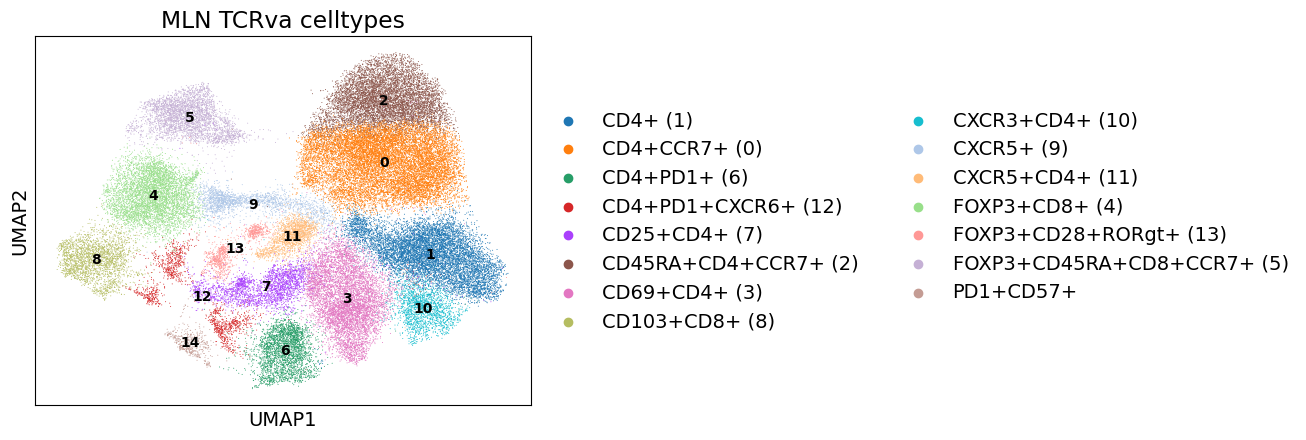

In [175]:
import scanpy as sc
import matplotlib.pyplot as plt

# Plot the UMAP
sc.pl.umap(
    sample,
    color=['celltype'],
    cmap='turbo',
    title = '{} {} celltypes'.format(tissue_type, sample_name),# Show legends directly on the UMAP
    show=False,            # Prevent immediate display
)

# Add cluster labels
ax = plt.gca()  # Get current axis
for cluster in sample.obs['leiden'].cat.categories:
    # Find the coordinates of cells in this cluster
    cluster_mask = sample.obs['leiden'] == cluster
    cluster_coords = sample.obsm['X_umap'][cluster_mask]
    # Calculate cluster centroid
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    # Add text label
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

# Display the plot
plt.show()

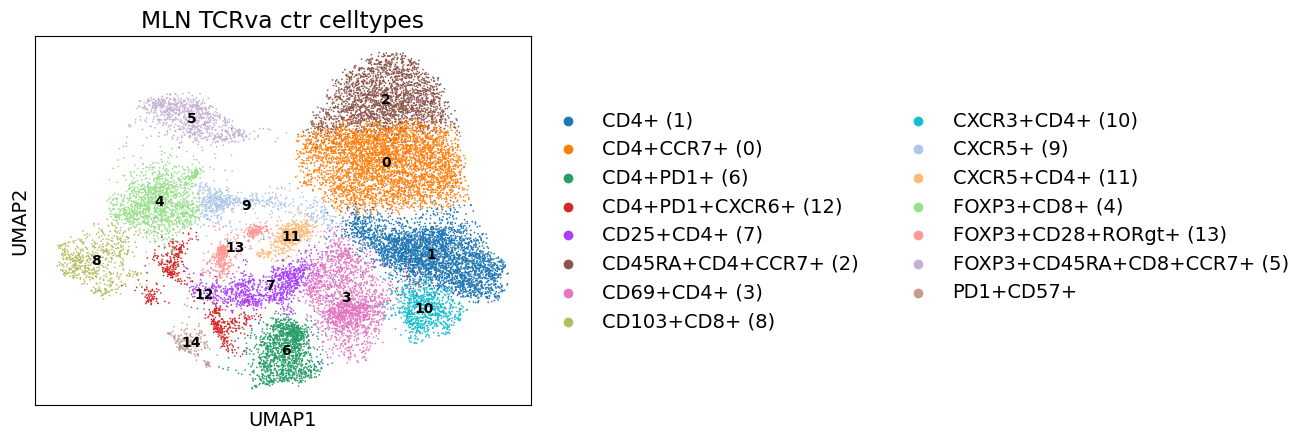

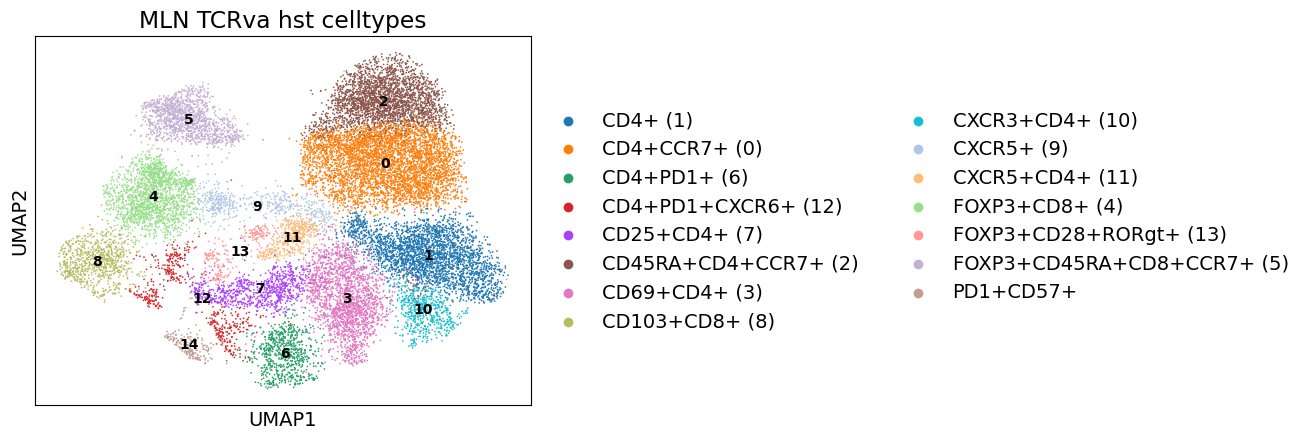

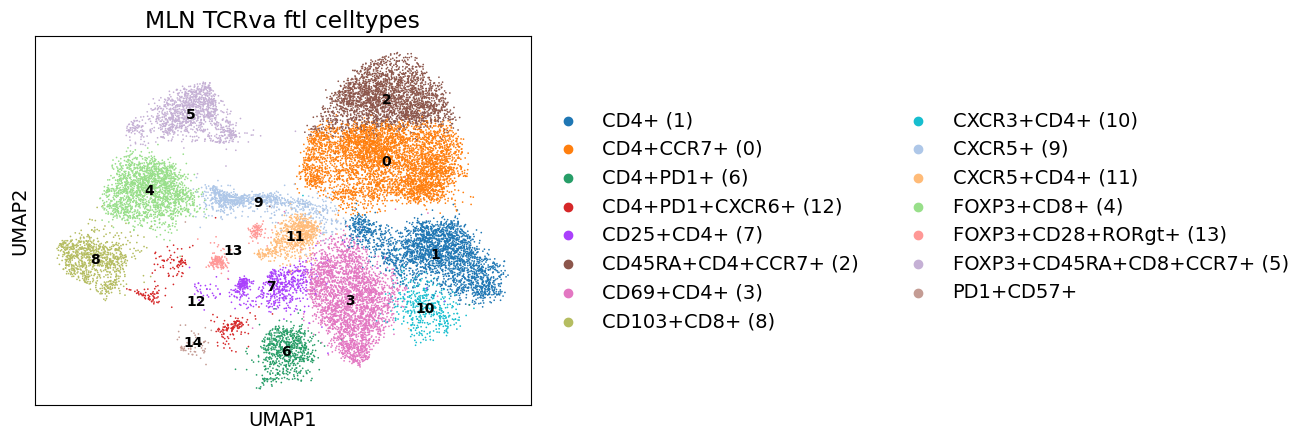

In [176]:
for group in ['ctr', 'hst', 'ftl']:
    adata_group = sample[sample.obs['group'] == group]
    
    sc.pl.umap(
    adata_group,
    color=['celltype'],
    title=f'{tissue_type} {sample_name} {group} celltypes',
    cmap='turbo', 
    show=False             
)

    ax = plt.gca()  
    for cluster in adata_group.obs['leiden'].cat.categories:
        cluster_mask = adata_group.obs['leiden'] == cluster
        cluster_coords = adata_group.obsm['X_umap'][cluster_mask]
        x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
        ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

    plt.show()

In [177]:
plt.rcParams.update({'font.size': 12})  

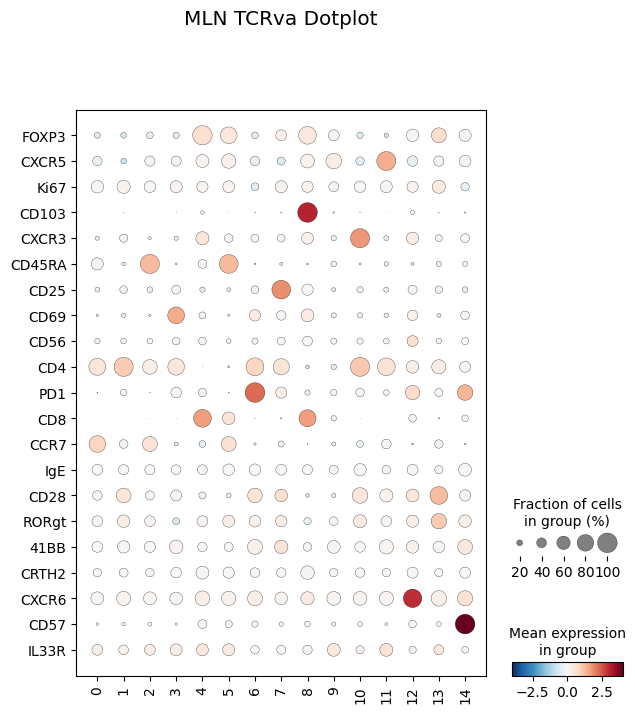

In [178]:
sc.pl.dotplot(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Dotplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)

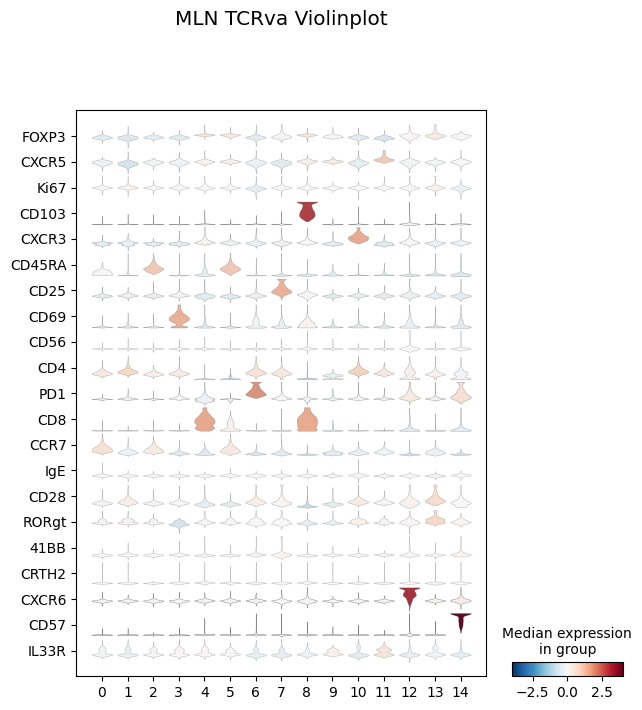

In [179]:
sc.pl.stacked_violin(sample, markers, swap_axes=True, groupby='leiden', title = "{} {} Violinplot".format(tissue_type, sample_name), cmap='RdBu_r', vmin = -4, vmax = 4)